In [1]:
import pandas as pd
df = pd.read_excel("villas.xlsx")

In [13]:
df.head()

,id,source,quartier,prix_mad,surface_m2,chambres_total,salles_de_bain,piscine,jardin,garage,securite,etat_bien,prix_m2
0,3642,agenz.ma,Anfa Superieur,6500000.0,600.0,5.0,2.0,0,0,0,0,NaN,10833.0
1,11328,agenz.ma,Ain Diab Extension,8900000.0,350.0,3.0,3.0,1,1,0,1,Bon état,25429.0
2,13485,agenz.ma,Californie,15470000.0,500.0,5.0,6.0,1,1,1,0,Bon état,30940.0
3,17997,agenz.ma,Californie,8300000.0,392.0,4.0,4.0,0,1,1,1,Bon état,21173.0
4,24332,agenz.ma,Ain Diab Extension,8600000.0,516.0,4.0,3.0,1,1,0,0,Bon état,16667.0


In [2]:
df['etat_bien'].value_counts()

etat_bien
Bon état         642
À rénover        246
Neuf / Rénové     58
Name: count, dtype: int64

In [28]:
df.describe()

,id,prix_mad,surface_m2,chambres_total,salles_de_bain,piscine,jardin,garage,securite,prix_m2
count,1.277000e+03,1.258000e+03,1277.000000,1240.000000,1247.000000,1277.000000,1277.000000,1277.000000,1277.000000,1.258000e+03
mean,6.510585e+06,1.662737e+07,790.857870,4.839516,3.718524,0.415818,0.752545,0.689115,0.222396,2.500244e+04
std,3.075041e+06,8.560350e+07,2867.205375,1.896657,1.435114,0.493056,0.431702,0.463037,0.416019,1.006005e+05
min,3.642000e+03,8.000000e+03,78.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,4.000000e+00
25%,6.881587e+06,6.800000e+06,400.000000,4.000000,3.000000,0.000000,1.000000,0.000000,0.000000,1.376400e+04
50%,8.177369e+06,9.900000e+06,540.000000,4.000000,4.000000,0.000000,1.000000,1.000000,0.000000,1.800000e+04
75%,8.297996e+06,1.500000e+07,800.000000,5.000000,4.000000,1.000000,1.000000,1.000000,0.000000,2.326975e+04
max,8.371408e+06,2.250000e+09,100000.000000,46.000000,12.000000,1.000000,1.000000,1.000000,1.000000,2.205882e+06


In [3]:
# suppression des vals aberrantes 

col = "prix_m2"
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR
under_bound = Q1 - 1.5 * IQR


df = df[(df[col] >= under_bound) & (df[col] <= upper_bound)]

<Axes: xlabel='prix_mad', ylabel='Count'>

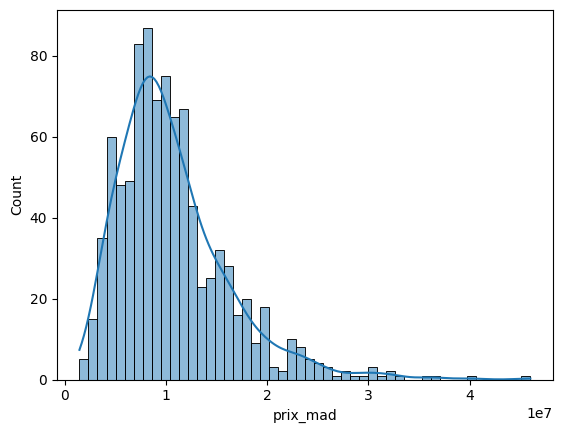

In [41]:
# distribution du prix m2 avec seaborn
import seaborn as sns
sns.histplot(df['prix_mad'], bins=50, kde=True)

In [4]:
# suppression des vals aberrantes 

col = "surface_m2"
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR
under_bound = Q1 - 1.5 * IQR


df = df[(df[col] >= under_bound) & (df[col] <= upper_bound)]

<Axes: xlabel='surface_m2', ylabel='Count'>

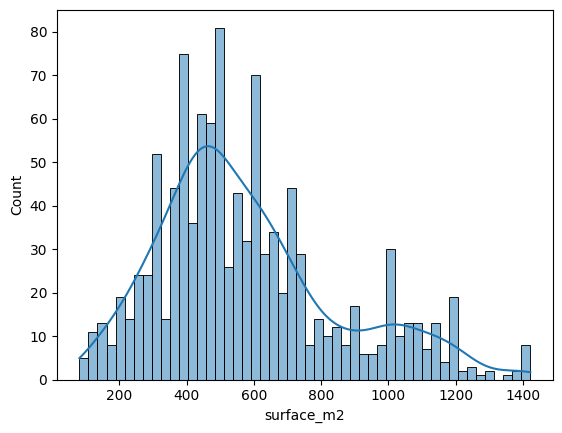

In [33]:
# distribution du prix m2 avec seaborn
import seaborn as sns
sns.histplot(df['surface_m2'], bins=50, kde=True)

In [17]:
df = df[df['prix_m2']>= 5000]

In [18]:
df.isna().sum()

id                  0
source              0
quartier            0
prix_mad            0
surface_m2          0
chambres_total     30
salles_de_bain     27
piscine             0
jardin              0
garage              0
securite            0
etat_bien         297
prix_m2             0
dtype: int64

In [5]:
# Médiane pour les variables numériques
df["salles_de_bain"] = df["salles_de_bain"].fillna(df["salles_de_bain"].median())
df["chambres_total"] = df["chambres_total"].fillna(df["chambres_total"].median())


In [6]:
# Supprimer les quartiers moins de 10 occurrences 
counts = df['quartier'].value_counts()
df = df[df['quartier'].isin(counts[counts >= 8].index)].copy()

In [29]:
df['quartier'].value_counts()

quartier
Californie                   200
Ain Diab                     110
Sidi Maarouf                  97
Polo                          57
Ain Diab Extension            55
Anfa                          51
Laymoune                      42
CIL (Hay Salam)               40
Anfa Superieur                35
Oulfa                         34
Longchamps (Hay Al Hanaa)     31
Oasis                         30
Mandarona                     20
Nassim 2                      15
Inara                         12
El Manar - El Hank            12
Ain Chock                     11
Ain Sebaa                     11
Al Qods                       10
Habbous                       10
Racine                         8
Les Princesses                 8
Hay Hassani                    8
Nassim 1                       8
Les Cretes                     8
Name: count, dtype: int64

In [7]:
df = df[df['quartier'] != "Villas & Maisons De Luxe Casablanca"]

# Modélisation — Estimation du prix au m²

In [53]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


cat_cols = ["quartier"]
num_cols = ["surface_m2", "chambres_total", "salles_de_bain",
            "piscine", "jardin", "garage", "securite"]

X = df[cat_cols + num_cols].copy()
y = df["prix_mad"] * 0.9

enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
X[cat_cols] = enc.fit_transform(X[cat_cols])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,
    stratify=df.loc[y.index, "quartier"]
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

results = {}

def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    mae  = mean_absolute_error(y_te, pred)
    rmse = np.sqrt(mean_squared_error(y_te, pred))
    r2   = r2_score(y_te, pred)
    results[name] = {"MAE": mae, "RMSE": rmse, "R2": r2}
    print(f"{name:30s} | MAE={mae:,.0f}  RMSE={rmse:,.0f}  R2={r2:.4f}")
    return model


Train: (738, 8), Test: (185, 8)


In [54]:
import joblib

joblib.dump(enc, "models/ordinal_encoder_quartiers_villas.pkl")

['models/ordinal_encoder_quartiers_villas.pkl']

## 1. Decision Tree & Random Forest

In [45]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

dt = evaluate("Decision Tree",
              DecisionTreeRegressor(max_depth=8, min_samples_leaf=5, random_state=42),
              X_train, y_train, X_test, y_test)

rf = evaluate("Random Forest",
              RandomForestRegressor(n_estimators=300, min_samples_leaf=3,
                                    n_jobs=-1, random_state=42),
              X_train, y_train, X_test, y_test)


Decision Tree                  | MAE=2,286,161  RMSE=3,398,218  R2=0.5378
Random Forest                  | MAE=2,159,542  RMSE=3,022,949  R2=0.6342


## 2. LightGBM

In [46]:
import lightgbm as lgb

lgbm = evaluate("LightGBM",
                lgb.LGBMRegressor(
                    n_estimators=1000, learning_rate=0.05, num_leaves=63,
                    min_child_samples=10, subsample=0.8, colsample_bytree=0.8,
                    reg_alpha=0.1, reg_lambda=1.0, random_state=42,
                    n_jobs=-1, verbose=-1
                ),
                X_train, y_train, X_test, y_test)


LightGBM                       | MAE=2,264,724  RMSE=3,155,648  R2=0.6014


## 3. CatBoost

In [44]:
from catboost import CatBoostRegressor

X_cat = df[cat_cols + num_cols].copy()
for c in cat_cols:
    X_cat[c] = X_cat[c].fillna("Inconnu")

y_cat = df["prix_mad"] * 0.9

X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(
    X_cat, y_cat, test_size=0.2, random_state=42,
    stratify=df.loc[y_cat.index, "quartier"]
)

cat_indices = [X_cat.columns.get_loc(c) for c in cat_cols]

cb = CatBoostRegressor(
    iterations=1000, learning_rate=0.05, depth=8,
    l2_leaf_reg=3, loss_function="RMSE", random_seed=42, verbose=0
)
cb.fit(X_train_cat, y_train_cat, cat_features=cat_indices)

pred_cb = cb.predict(X_test_cat)
mae_cb  = mean_absolute_error(y_test_cat, pred_cb)
rmse_cb = np.sqrt(mean_squared_error(y_test_cat, pred_cb))
r2_cb   = r2_score(y_test_cat, pred_cb)
results["CatBoost"] = {"MAE": mae_cb, "RMSE": rmse_cb, "R2": r2_cb}
print(f"{"CatBoost":30s} | MAE={mae_cb:,.0f}  RMSE={rmse_cb:,.0f}  R2={r2_cb:.4f}")


CatBoost                       | MAE=2,015,453  RMSE=2,865,611  R2=0.6713


## 4. Validation croisée : CatBoost

In [48]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from catboost import Pool, CatBoostRegressor

X_cv = df[cat_cols + num_cols].copy()

for c in cat_cols:
    X_cv[c] = X_cv[c].fillna('Inconnu')

y_cv = df['prix_mad'] * 0.9
strat_groups = df['quartier'].values
quartier_encoded = LabelEncoder().fit_transform(strat_groups)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_maes, cv_rmses, cv_r2s = [], [], []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_cv, quartier_encoded)):
    X_tr_f, X_val_f = X_cv.iloc[tr_idx], X_cv.iloc[val_idx]
    y_tr_f, y_val_f = y_cv.iloc[tr_idx], y_cv.iloc[val_idx]

    pool_tr  = Pool(X_tr_f,  y_tr_f,  cat_features=cat_cols)
    pool_val = Pool(X_val_f, y_val_f, cat_features=cat_cols)

    cb_cv = CatBoostRegressor(
        iterations=1000, learning_rate=0.05, depth=8,
        l2_leaf_reg=3, loss_function='RMSE', random_seed=42, verbose=0
    )
    cb_cv.fit(pool_tr, eval_set=pool_val, early_stopping_rounds=50)

    pred_val = cb_cv.predict(X_val_f)
    cv_maes.append(mean_absolute_error(y_val_f, pred_val))
    cv_rmses.append(np.sqrt(mean_squared_error(y_val_f, pred_val)))
    cv_r2s.append(r2_score(y_val_f, pred_val))
    print(f"  Fold {fold+1} | MAE={cv_maes[-1]:,.0f}  RMSE={cv_rmses[-1]:,.0f}  R²={cv_r2s[-1]:.4f}")

print(f"\n{'CV moyen':30s} | MAE={np.mean(cv_maes):,.0f} ± {np.std(cv_maes):,.0f}"
      f"  RMSE={np.mean(cv_rmses):,.0f} ± {np.std(cv_rmses):,.0f}"
      f"  R²={np.mean(cv_r2s):.4f} ± {np.std(cv_r2s):.4f}")

  Fold 1 | MAE=1,673,560  RMSE=2,315,300  R²=0.6901
  Fold 2 | MAE=2,016,694  RMSE=2,840,910  R²=0.6966
  Fold 3 | MAE=2,051,356  RMSE=2,763,258  R²=0.6916
  Fold 4 | MAE=1,972,430  RMSE=3,045,634  R²=0.6656
  Fold 5 | MAE=2,105,306  RMSE=3,070,268  R²=0.6747

CV moyen                       | MAE=1,963,869 ± 151,527  RMSE=2,807,074 ± 272,429  R²=0.6837 ± 0.0117


## 5. Optimisation des hyperparamètres : Optuna + CatBoost

In [49]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'iterations':       trial.suggest_int('iterations', 500, 2000),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'depth':            trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg':      trial.suggest_float('l2_leaf_reg', 1, 10, log=True),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'random_strength':  trial.suggest_float('random_strength', 0.0, 2.0),
        'border_count':     trial.suggest_int('border_count', 32, 255),
        'loss_function': 'RMSE',
        'random_seed': 42,
        'verbose': 0,
    }

    fold_rmses = []
    for tr_idx, val_idx in skf.split(X_cv, quartier_encoded):
        X_tr_f, X_val_f = X_cv.iloc[tr_idx], X_cv.iloc[val_idx]
        y_tr_f, y_val_f = y_cv.iloc[tr_idx], y_cv.iloc[val_idx]

        model = CatBoostRegressor(**params)
        model.fit(
            Pool(X_tr_f, y_tr_f, cat_features=cat_cols),
            eval_set=Pool(X_val_f, y_val_f, cat_features=cat_cols),
            early_stopping_rounds=50,
        )
        pred = model.predict(X_val_f)
        fold_rmses.append(np.sqrt(mean_squared_error(y_val_f, pred)))

    return np.mean(fold_rmses)

study = optuna.create_study(direction='minimize',
                            sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=15, show_progress_bar=True)

print(f"\nMeilleur RMSE CV : {study.best_value:,.0f}")
print("Meilleurs hyperparamètres :")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

c:\Users\del\Desktop\prix-immobilier-evaluation\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Best trial: 6. Best value: 2.74771e+06: 100%|██████████| 15/15 [12:30<00:00, 50.02s/it]


Meilleur RMSE CV : 2,747,708
Meilleurs hyperparamètres :
  iterations: 551
  learning_rate: 0.15242391728466367
  depth: 5
  l2_leaf_reg: 4.597505784732165
  bagging_temperature: 0.31171107608941095
  random_strength: 1.0401360423556216
  border_count: 154


In [50]:
# Ré-entraînement du meilleur modèle sur tout le train
best_params = study.best_params.copy()
best_params.update({'loss_function': 'RMSE', 'random_seed': 42, 'verbose': 0})

cb_best = CatBoostRegressor(**best_params)
cb_best.fit(
    Pool(X_train_cat, y_train_cat, cat_features=cat_cols),
    eval_set=Pool(X_test_cat, y_test_cat, cat_features=cat_cols),
    early_stopping_rounds=50,
)

pred_best = cb_best.predict(X_test_cat)
mae_best  = mean_absolute_error(y_test_cat, pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test_cat, pred_best))
r2_best   = r2_score(y_test_cat, pred_best)
results['CatBoost (Optuna)'] = {'MAE': mae_best, 'RMSE': rmse_best, 'R²': r2_best}
print(f"{'CatBoost (Optuna)':30s} | MAE={mae_best:,.0f}  RMSE={rmse_best:,.0f}  R²={r2_best:.4f}")

CatBoost (Optuna)              | MAE=1,973,286  RMSE=2,830,148  R²=0.6794


## Enregistrement du modèle CatBoost

In [52]:
import json, os

os.makedirs('models', exist_ok=True)

# Sauvegarde du modèle
cb_best.save_model('models/catboost_prix_villa.cbm')

# Métadonnées
meta = {
    'features': cat_cols + num_cols,
    'cat_features': cat_cols,
    'target': 'prix_m2',
    'test_metrics': {'MAE': round(mae_best, 2), 'RMSE': round(rmse_best, 2), 'R2': round(r2_best, 4)},
    'best_params': study.best_params,
}
with open('models/catboost_prix_villa_meta.json', 'w', encoding='utf-8') as f:
    json.dump(meta, f, indent=2, ensure_ascii=False)

print("Modèle sauvegardé        : models/catboost_prix_villa.cbm")
print("Métadonnées sauvegardées : models/catboost_prix_villa_meta.json")
print(f"\nPerformances finales — CatBoost (Optuna)")
print(f"  MAE  : {mae_best:,.0f} MAD/m²")
print(f"  RMSE : {rmse_best:,.0f} MAD/m²")
print(f"  R²   : {r2_best:.4f}")

Modèle sauvegardé        : models/catboost_prix_villa.cbm
Métadonnées sauvegardées : models/catboost_prix_villa_meta.json

Performances finales — CatBoost (Optuna)
  MAE  : 1,973,286 MAD/m²
  RMSE : 2,830,148 MAD/m²
  R²   : 0.6794
